# Trabajo Práctico 2

## Objetivo:

Implementar un detector de máximo enfoque sobre un video aplicando técnicasde análisis espectral similar al que utilizan las cámaras digitales modernas. El video a procesar será: “focus_video.mov”.

1. Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper `"Image Sharpness Measure for Blurred Images in Frequency Domain“` y realizar dos experimentos:
    1. Medición sobre todo el frame.
    2. Medición sobre una ROI ubicada en el centro del frame. Area de la ROI = 5 o 10% del area total del frame.
    Para cada experimento se debe presentar :
    - Una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuando el algoritmo detecto la región de máximo enfoque.

El algoritmo de detección a implementar debe detectar y devolver los puntos de máximo enfoque de manera automática.

**Puntos extra:** Aplicar unsharp masking para expandir la zona de enfoque y devolver.

# $$ --- RESOLUCION --- $$

## 0) Configuración

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

VIDEO_PATH = "focus_video.mov"     # debe estar en la misma carpeta que el notebook
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

SMOOTH_WINDOW = 7       # frames (impar). Ventana de la media móvil
PLATEAU_FRAC = 0.95     # meseta = frames con FM >= 95% del rango (min→max)
SAVE_OVERLAY_VIDEO = True   # generar video con la grilla superpuesta (tarda unos segundos)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

## 1) Métrica FM (sección 3.1 del paper)

1. `F` = FFT2 de la imagen.
2. `Fc` = `F` centrada (`fftshift`).
3. `AF = |Fc|`.
4. `max_val = max(AF)`.
5. `thres = max_val / 1000`.
6. `T_H` = cantidad de píxeles de `AF` con valor `> thres`.
7. `FM = T_H / (filas × columnas)`.

Una imagen desenfocada pierde componentes de alta frecuencia, por lo que menos coeficientes superan el umbral → **FM más bajo**. Una imagen enfocada conserva más frecuencias → **FM más alto**.

In [2]:
def fm_metric(gray_img: np.ndarray, thres_div: float = 1000.0) -> float:
    '''Métrica FM del paper (Sec. 3.1). `thres_div=1000` es el valor original.'''
    if gray_img.ndim == 3:
        gray_img = cv2.cvtColor(gray_img, cv2.COLOR_BGR2GRAY)

    F = np.fft.fft2(gray_img.astype(np.float64))
    AF = np.abs(np.fft.fftshift(F))

    thres = AF.max() / thres_div
    T_H = np.count_nonzero(AF > thres)
    rows, cols = gray_img.shape
    return T_H / (rows * cols)


def center_roi(gray_img: np.ndarray, area_fraction: float) -> np.ndarray:
    '''ROI centrada cuya área es `area_fraction` del área total (misma relación de aspecto).'''
    h, w = gray_img.shape[:2]
    s = np.sqrt(area_fraction)
    rh, rw = max(1, int(h * s)), max(1, int(w * s))
    y0, x0 = (h - rh) // 2, (w - rw) // 2
    return gray_img[y0:y0 + rh, x0:x0 + rw]

## 2) Lectura del video y cálculo de FM frame a frame

In [3]:
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(
        f"No se pudo abrir '{VIDEO_PATH}'. Verificá que esté en el mismo directorio que el notebook."
    )

fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"FPS: {fps:.2f} | Resolución: {width}x{height}")

frames_bgr, frames_gray = [], []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames_bgr.append(frame)
    frames_gray.append(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY))
cap.release()

n_frames = len(frames_gray)
print(f"Frames leídos: {n_frames}  ({n_frames / fps:.2f} s)")

fm_full = np.array([fm_metric(g) for g in frames_gray])
fm_roi5 = np.array([fm_metric(center_roi(g, 0.05)) for g in frames_gray])
fm_roi10 = np.array([fm_metric(center_roi(g, 0.10)) for g in frames_gray])

FPS: 29.97 | Resolución: 640x360
Frames leídos: 171  (5.71 s)


## 3) Detección automática del máximo enfoque

`detect_max_focus` recibe la curva de FM y devuelve un diccionario con:

- `best_frame`: frame del máximo global de la curva suavizada (`np.argmax`).
- `plateau`: rango contiguo de frames alrededor del máximo cuyo FM está al ≥ 95% del rango de la curva. Sirve para saber cuán **agudo** es el pico (una meseta ancha indica que varios frames están casi igual de enfocados y que el argmax es sensible al ruido).
- `curve`: curva suavizada.

**Suavizado.** La curva de FM frame a frame tiene ruido, por lo que se suaviza con una **media móvil de 7 frames** (≈0.23 s): es un filtro lineal 1D de núcleo uniforme y ganancia unitaria, con *padding* de borde para conservar el largo de la curva. La ventana es un compromiso: una ventana mayor achata el pico y lo corre hacia atrás (con 11 frames, el máximo del frame completo se movía al frame 108 y la meseta se ensanchaba mucho).

In [4]:
def smooth(curve, window=SMOOTH_WINDOW):
    """Media móvil: filtro lineal 1D de núcleo uniforme y ganancia unitaria (suma de coeficientes = 1).
    Se usa padding de borde para que la salida tenga el mismo largo que la entrada."""
    curve = np.asarray(curve, dtype=float)
    window = min(window, len(curve))
    if window % 2 == 0:
        window += 1
    kernel = np.ones(window) / window
    padded = np.pad(curve, window // 2, mode="edge")
    return np.convolve(padded, kernel, mode="valid")


def detect_max_focus(curve, window=SMOOTH_WINDOW, plateau_frac=PLATEAU_FRAC):
    """Detecta automáticamente el frame de máximo enfoque.

    Devuelve dict con: best_frame, plateau=(inicio, fin), curve (suavizada).
    """
    s = smooth(curve, window)
    best = int(np.argmax(s))

    thr = s.min() + plateau_frac * (s.max() - s.min())
    lo = best
    while lo > 0 and s[lo - 1] >= thr:
        lo -= 1
    hi = best
    while hi < len(s) - 1 and s[hi + 1] >= thr:
        hi += 1

    return {"best_frame": best, "plateau": (lo, hi), "curve": s}


def plot_focus_curve(ax, raw, res, label, color="tab:blue"):
    ax.plot(raw, color=color, alpha=0.35, label=f"FM crudo ({label})")
    ax.plot(res["curve"], color=color, linewidth=2, label="FM suavizado")
    lo, hi = res["plateau"]
    ax.axvspan(lo, hi, color="gold", alpha=0.25, label=f"Meseta ≥{PLATEAU_FRAC:.0%}: frames {lo}–{hi}")
    b = res["best_frame"]
    ax.scatter([b], [res["curve"][b]], color="red", s=90, zorder=6, label=f"Máximo (frame {b})")
    ax.set_xlabel("Frame")
    ax.set_ylabel("FM")
    ax.legend(loc="upper left")


res_full = detect_max_focus(fm_full)
res_roi5 = detect_max_focus(fm_roi5)
res_roi10 = detect_max_focus(fm_roi10)

## Experimento 1 — FM sobre el frame completo

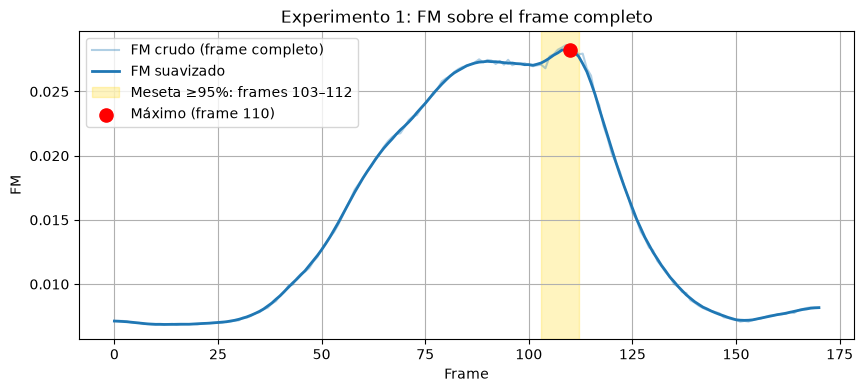

Frame de máximo enfoque: 110 (t = 3.67 s) | meseta: (103, 112)


In [5]:
fig, ax = plt.subplots()
plot_focus_curve(ax, fm_full, res_full, "frame completo")
ax.set_title("Experimento 1: FM sobre el frame completo")
fig.savefig(OUTPUT_DIR / "exp1_frame_completo.png", dpi=150, bbox_inches="tight")
plt.show()

b = res_full["best_frame"]
print(f"Frame de máximo enfoque: {b} (t = {b / fps:.2f} s) | meseta: {res_full['plateau']}")

**Interpretación.** La curva de FM sobre el frame completo comienza baja y relativamente estable, sube gradualmente y alcanza su máximo alrededor del frame 110. Luego cae con rapidez. La meseta cercana al máximo indica que el foco se mantiene bueno durante varios frames.

## Experimento 2 — FM sobre ROI centrada (5% y 10% del área)

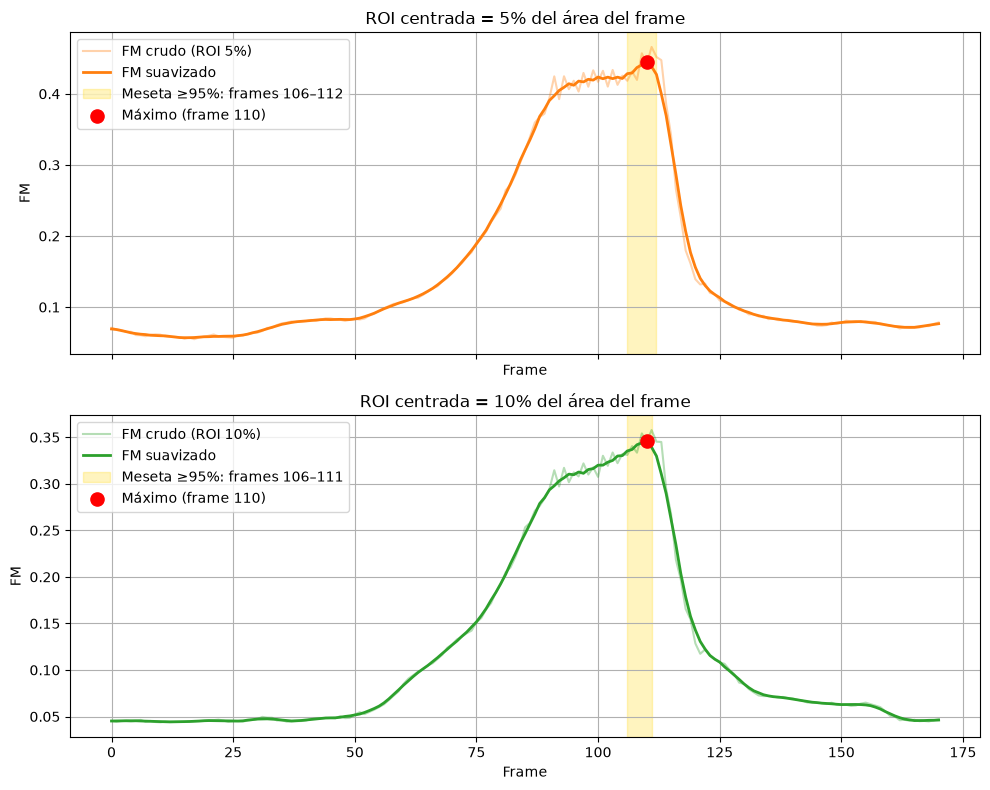

ROI 5%: máximo en frame 110 (t = 3.67 s) | meseta: (106, 112)
ROI 10%: máximo en frame 110 (t = 3.67 s) | meseta: (106, 111)


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
plot_focus_curve(axes[0], fm_roi5, res_roi5, "ROI 5%", "tab:orange")
axes[0].set_title("ROI centrada = 5% del área del frame")
plot_focus_curve(axes[1], fm_roi10, res_roi10, "ROI 10%", "tab:green")
axes[1].set_title("ROI centrada = 10% del área del frame")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "exp2_roi_centrada.png", dpi=150, bbox_inches="tight")
plt.show()

for name, r in [("ROI 5%", res_roi5), ("ROI 10%", res_roi10)]:
    b = r["best_frame"]
    print(f"{name}: máximo en frame {b} (t = {b / fps:.2f} s) | meseta: {r['plateau']}")

**Interpretación.** Las curvas sobre la ROI centrada tienen la misma tendencia general, pero con una subida más tardía y una caída más abrupta. Esto sugiere que la región central responde de forma más concentrada alrededor del punto de enfoque, con un pico más localizado. En todos los casos, el máximo se ubica cerca del frame 110.

### Comparación de las curvas normalizadas

Los valores absolutos de FM **no son comparables** entre regiones de distinto tamaño (la métrica depende del área y del umbral `max/1000`). Por eso se comparan normalizadas (0–1): lo que importa es la forma de la curva y la posición del pico.

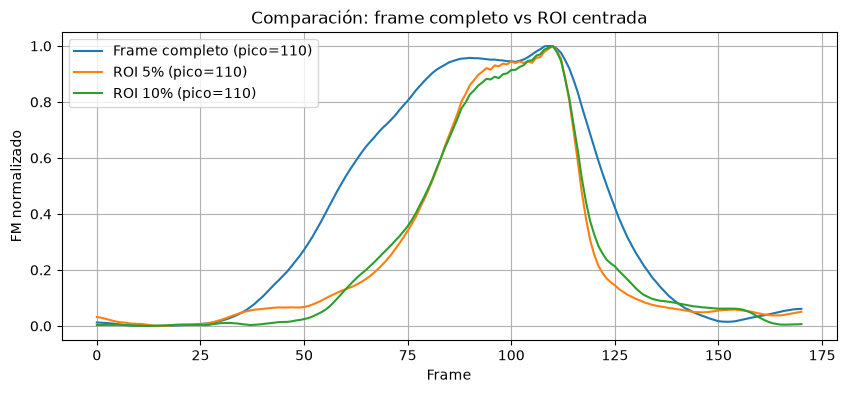

In [7]:
def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

fig, ax = plt.subplots()
for r, lbl in [(res_full, "Frame completo"), (res_roi5, "ROI 5%"), (res_roi10, "ROI 10%")]:
    ax.plot(normalize(r["curve"]), label=f"{lbl} (pico={r['best_frame']})")
ax.set_xlabel("Frame")
ax.set_ylabel("FM normalizado")
ax.set_title("Comparación: frame completo vs ROI centrada")
ax.legend()
fig.savefig(OUTPUT_DIR / "comparacion_curvas.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación.** Una vez normalizadas, las tres curvas apuntan al mismo intervalo temporal, lo que confirma que la métrica es consistente. La diferencia principal está en la forma: el frame completo cambia más suavemente, mientras que las ROI responden con menos suavidad y un pico más marcado.

### Frames de máximo enfoque detectados

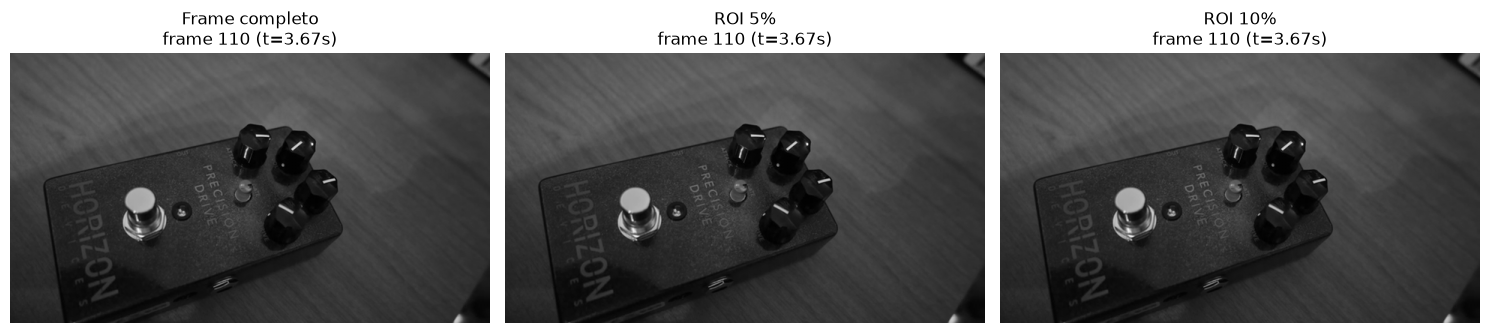

True

In [8]:
best_full = res_full["best_frame"]
best_roi5 = res_roi5["best_frame"]
best_roi10 = res_roi10["best_frame"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, i) in zip(axes, [("Frame completo", best_full), ("ROI 5%", best_roi5), ("ROI 10%", best_roi10)]):
    ax.imshow(frames_gray[i], cmap="gray")
    ax.set_title(f"{label}\nframe {i} (t={i / fps:.2f}s)")
    ax.axis("off")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "frames_max_enfoque.png", dpi=150, bbox_inches="tight")
plt.show()

cv2.imwrite(str(OUTPUT_DIR / f"best_focus_full_frame{best_full}.png"), frames_bgr[best_full])
cv2.imwrite(str(OUTPUT_DIR / f"best_focus_roi5_frame{best_roi5}.png"), frames_bgr[best_roi5])
cv2.imwrite(str(OUTPUT_DIR / f"best_focus_roi10_frame{best_roi10}.png"), frames_bgr[best_roi10])

Los frames detectados por FM como mejor enfocados coinciden en el mismo rango temporal. 

## 4) Sensibilidad al umbral de la métrica

El paper usa `thres = max/1000`. Se verifica cuánto depende el resultado de ese divisor:

- `max/100` es un umbral **más alto**: solo lo superan los coeficientes de mayor energía y FM casi no varía entre frames.
- `max/10000` es un umbral **más bajo**: pasan más coeficientes, incluidos los de baja energía, que pueden ser ruido.

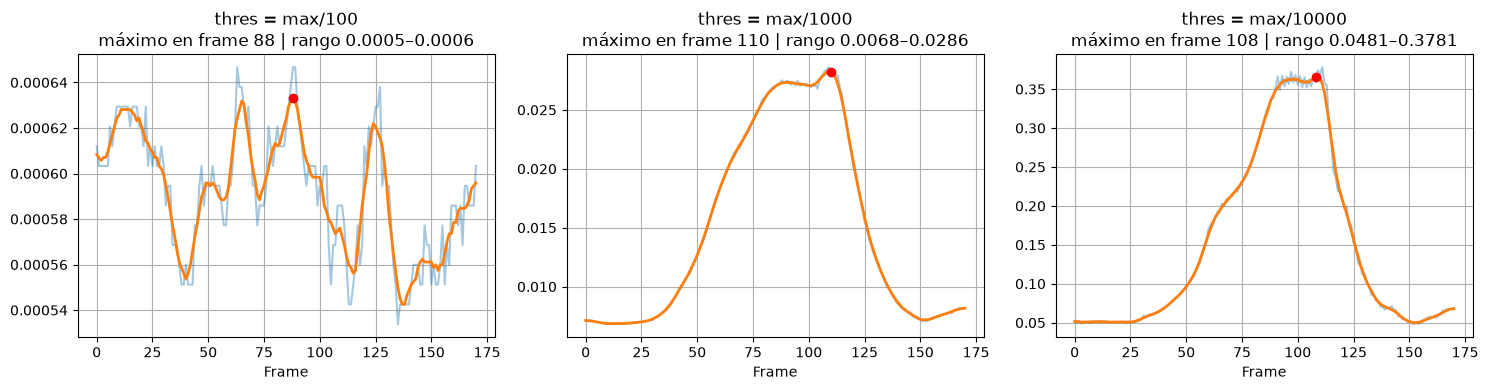

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, div in zip(axes, [100, 1000, 10000]):
    curve = np.array([fm_metric(g, thres_div=div) for g in frames_gray])
    r = detect_max_focus(curve)
    ax.plot(curve, alpha=0.4)
    ax.plot(r["curve"], linewidth=2)
    ax.scatter([r["best_frame"]], [r["curve"][r["best_frame"]]], color="red", zorder=5)
    ax.set_title(f"thres = max/{div}\nmáximo en frame {r['best_frame']} | rango {curve.min():.4f}–{curve.max():.4f}")
    ax.set_xlabel("Frame")
plt.tight_layout()
plt.show()

**Interpretación.**  Con un umbral más alto (`max/100`), la métrica pierde sensibilidad y la curva se vuelve plana y poco informativa. Con el umbral del paper (`max/1000`) y con uno más bajo (`max/10000`), la respuesta es más estable y coherente, y el máximo cae en frames cercanos (110 y 108). Esto confirma que `max/1000` es una elección razonable para este caso.

## 5) Validación con un filtro de bordes (Sobel)

Se compara FM con la **energía del gradiente de Sobel**: el promedio de G² = Gx² + Gy², donde Gx y Gy son las respuestas de los filtros de Sobel en x e y (la misma magnitud de gradiente que se usa en Canny). Bordes y ruido son componentes de alta frecuencia: un frame enfocado, con bordes más marcados, debería dar una respuesta mayor que uno desenfocado. Si dos métricas de naturaleza distinta coinciden en el frame de máximo enfoque, hay evidencia de que FM detecta correctamente.

> Nota: Sobel se calcula en `CV_64F` para no perder las pendientes negativas.

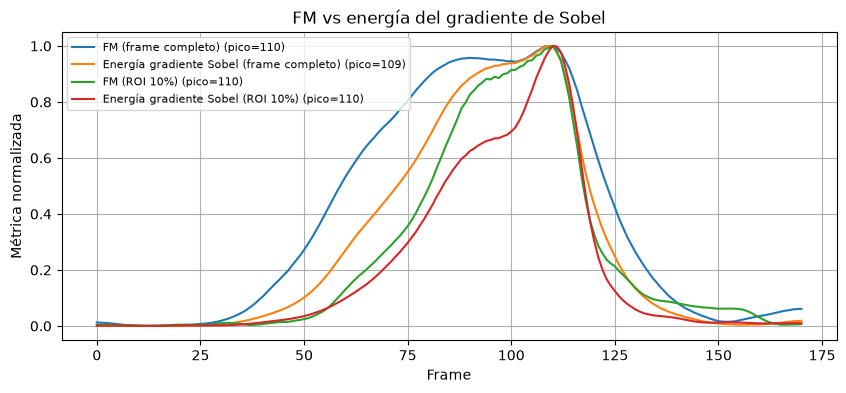

FM (frame completo)                        -> pico: 110 | meseta: (103, 112)
Energía gradiente Sobel (frame completo)   -> pico: 109 | meseta: (104, 111)
FM (ROI 10%)                               -> pico: 110 | meseta: (106, 111)
Energía gradiente Sobel (ROI 10%)          -> pico: 110 | meseta: (108, 112)


In [10]:
def sobel_energy(g):
    gx = cv2.Sobel(g, cv2.CV_64F, 1, 0)
    gy = cv2.Sobel(g, cv2.CV_64F, 0, 1)
    return np.mean(gx ** 2 + gy ** 2)

sobel_full = np.array([sobel_energy(g) for g in frames_gray])
sobel_roi10 = np.array([sobel_energy(center_roi(g, 0.10)) for g in frames_gray])

ref = {
    "FM (frame completo)": res_full,
    "Energía gradiente Sobel (frame completo)": detect_max_focus(sobel_full),
    "FM (ROI 10%)": res_roi10,
    "Energía gradiente Sobel (ROI 10%)": detect_max_focus(sobel_roi10),
}

fig, ax = plt.subplots()
for name, r in ref.items():
    ax.plot(normalize(r["curve"]), label=f"{name} (pico={r['best_frame']})")
ax.set_xlabel("Frame")
ax.set_ylabel("Métrica normalizada")
ax.set_title("FM vs energía del gradiente de Sobel")
ax.legend(fontsize=8)
fig.savefig(OUTPUT_DIR / "validacion_metricas.png", dpi=150, bbox_inches="tight")
plt.show()

for name, r in ref.items():
    print(f"{name:42s} -> pico: {r['best_frame']:3d} | meseta: {r['plateau']}")

**Interpretación.** FM y la energía del gradiente de Sobel, aunque miden distinta información, ubican el máximo en frames muy cercanos. Esa coincidencia aporta evidencia adicional de que la detección del enfoque es robusta.

## 6) Matriz de enfoque (grilla tipo autofocus multipunto)

Se calcula FM sobre una grilla de celdas (7×8) y se muestra qué zona del frame está más enfocada. Para la curva global se comparan tres agregaciones:

- **Promedio** de todas las celdas (incluye mucho fondo sin textura → diluye la señal).
- **Máximo** de las celdas (muy sensible al ruido de una sola celda).
- **Promedio del top 25%** de celdas (compromiso: sigue a las regiones con contenido).

In [11]:
N_ROWS, N_COLS = 7, 8


def focus_grid_fm(gray_img, n_rows=N_ROWS, n_cols=N_COLS, margin_frac=0.15):
    '''FM en cada celda de una grilla n_rows x n_cols (con margen en los bordes).

    Devuelve (fm_grid [n_rows, n_cols], boxes[r][c] = (x, y, w, h)).'''
    h, w = gray_img.shape[:2]
    x0, x1 = int(w * margin_frac), int(w * (1 - margin_frac))
    y0, y1 = int(h * margin_frac), int(h * (1 - margin_frac))
    cell_w = max(1, (x1 - x0) // n_cols)
    cell_h = max(1, (y1 - y0) // n_rows)

    fm_grid = np.zeros((n_rows, n_cols))
    boxes = []
    for r in range(n_rows):
        row_boxes = []
        for c in range(n_cols):
            cx0, cy0 = x0 + c * cell_w, y0 + r * cell_h
            fm_grid[r, c] = fm_metric(gray_img[cy0:cy0 + cell_h, cx0:cx0 + cell_w])
            row_boxes.append((cx0, cy0, cell_w, cell_h))
        boxes.append(row_boxes)
    return fm_grid, boxes


def draw_focus_grid(frame_bgr, fm_grid, boxes, cmap_name="RdYlGn", thickness=2):
    '''Dibuja la grilla sobre una copia del frame: verde = más nítido, rojo = menos nítido.'''
    img = frame_bgr.copy()
    cmap = plt.get_cmap(cmap_name)
    vmin, vmax = fm_grid.min(), fm_grid.max()
    span = (vmax - vmin) or 1e-12
    for r in range(fm_grid.shape[0]):
        for c in range(fm_grid.shape[1]):
            x, y, w_, h_ = boxes[r][c]
            rgb = cmap((fm_grid[r, c] - vmin) / span)[:3]
            bgr = tuple(int(255 * ch) for ch in rgb[::-1])
            cv2.rectangle(img, (x, y), (x + w_, y + h_), bgr, thickness)
    return img


# Se calcula la grilla una sola vez por frame y se reutiliza
grids = [focus_grid_fm(g)[0] for g in frames_gray]
_, boxes = focus_grid_fm(frames_gray[0])

k_top = max(1, int(0.25 * N_ROWS * N_COLS))
fm_grid_mean = np.array([g.mean() for g in grids])
fm_grid_max = np.array([g.max() for g in grids])
fm_grid_top = np.array([np.sort(g.ravel())[-k_top:].mean() for g in grids])

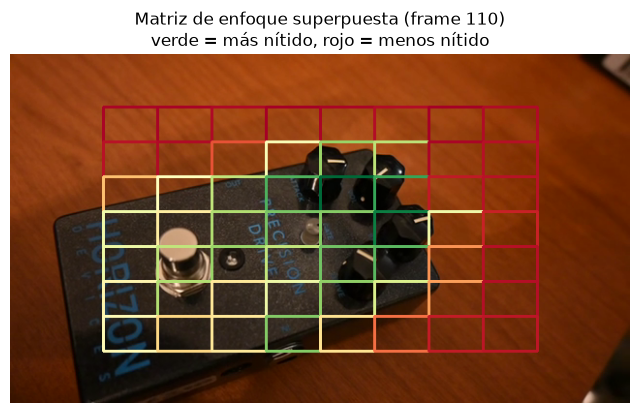

In [12]:
# Grilla superpuesta sobre el frame de mejor enfoque (definido por el frame completo)
overlay = draw_focus_grid(frames_bgr[best_full], grids[best_full], boxes)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"Matriz de enfoque superpuesta (frame {best_full})\nverde = más nítido, rojo = menos nítido")
plt.axis("off")
plt.savefig(OUTPUT_DIR / "matriz_enfoque_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

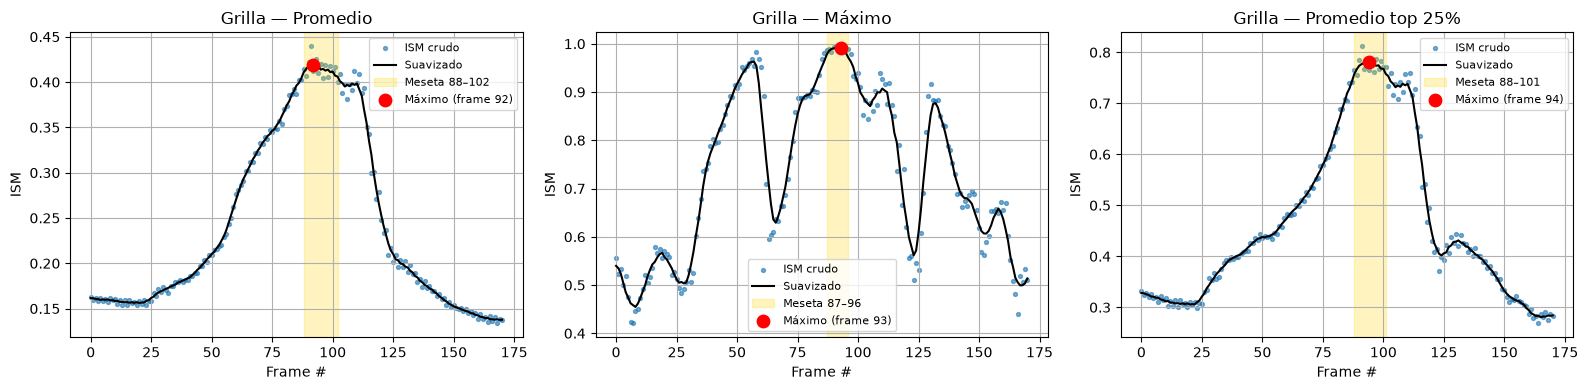

Grilla (Promedio        ) -> máximo en frame  92 | meseta (88, 102)
Grilla (Máximo          ) -> máximo en frame  93 | meseta (87, 96)
Grilla (Promedio top 25%) -> máximo en frame  94 | meseta (88, 101)


In [13]:
res_grid = {
    "Promedio": detect_max_focus(fm_grid_mean),
    "Máximo": detect_max_focus(fm_grid_max),
    "Promedio top 25%": detect_max_focus(fm_grid_top),
}
raws = {"Promedio": fm_grid_mean, "Máximo": fm_grid_max, "Promedio top 25%": fm_grid_top}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, r) in zip(axes, res_grid.items()):
    ax.scatter(range(n_frames), raws[name], s=8, alpha=0.6, label="ISM crudo")
    ax.plot(r["curve"], color="black", linewidth=1.5, label="Suavizado")
    lo, hi = r["plateau"]
    ax.axvspan(lo, hi, color="gold", alpha=0.25, label=f"Meseta {lo}–{hi}")
    ax.scatter([r["best_frame"]], [r["curve"][r["best_frame"]]], color="red", s=80, zorder=5,
               label=f"Máximo (frame {r['best_frame']})")
    ax.set_title(f"Grilla — {name}")
    ax.set_xlabel("Frame #")
    ax.set_ylabel("ISM")
    ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "matriz_enfoque_curva.png", dpi=150, bbox_inches="tight")
plt.show()

for name, r in res_grid.items():
    print(f"Grilla ({name:16s}) -> máximo en frame {r['best_frame']:3d} | meseta {r['plateau']}")

**Interpretación.** La agregación por promedio de la grilla mueve el máximo a un intervalo anterior, mientras que el máximo de celda resulta más ruidoso y menos estable. Esto muestra que la forma de combinar la información de la grilla influye bastante en el resultado.

In [14]:
if SAVE_OVERLAY_VIDEO:
    out_path = str(OUTPUT_DIR / "focus_grid_overlay.mp4")
    vw = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))
    curve = normalize(res_full["curve"])
    for i, frame in enumerate(frames_bgr):
        img = draw_focus_grid(frame, grids[i], boxes)
        cv2.putText(img, f"frame {i}  FM={fm_full[i]:.4f}", (10, 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
        if i == best_full:
            cv2.putText(img, "MAX ENFOQUE", (10, 55), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2, cv2.LINE_AA)
        # mini-curva de FM abajo
        pts = np.array([[int(j / (n_frames - 1) * (width - 20)) + 10,
                         height - 10 - int(curve[j] * 50)] for j in range(i + 1)], np.int32)
        if len(pts) > 1:
            cv2.polylines(img, [pts], False, (0, 255, 255), 2, cv2.LINE_AA)
        vw.write(img)
    vw.release()
    print("Video guardado en", out_path)

Video guardado en outputs\focus_grid_overlay.mp4


## 7) Punto extra — Unsharp masking

$$g(x,y) = (k+1)\,f(x,y) - k\,f_B(x,y)$$

donde $f_B$ es la imagen desenfocada con un Gaussiano y $k$ es la ganancia (k=1 → unsharp masking, k>1 → high-boost).

**Criterio de evaluación.** Que el FM suba después del unsharp es esperable: el filtro amplifica las altas frecuencias por construcción (también el ruido y los artefactos de compresión), por lo que ese aumento no alcanza para concluir que la zona de enfoque se expandió. Por eso, además del FM de un frame, se evalúa si al aplicar unsharp a **todos los frames** la **meseta de enfoque se ensancha**, es decir, si aumenta el rango de frames aceptablemente enfocados.

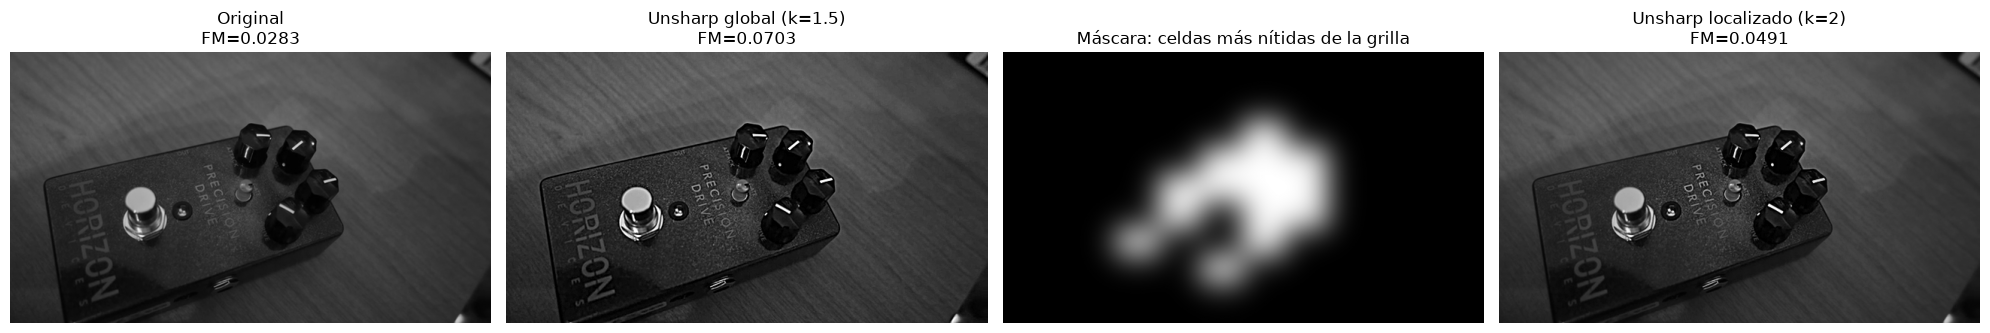

True

In [15]:
def unsharp_mask(img, sigma=2.0, k=1.5):
    '''g = (k+1)*f - k*f_blur  (opera y devuelve uint8).'''
    blurred = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma)
    return cv2.addWeighted(img, 1 + k, blurred, -k, 0)


def local_unsharp(img, weights, sigma=2.0, k=2.0):
    '''Unsharp más fuerte donde `weights` (0-1) es alto; transición suave.'''
    sharp = unsharp_mask(img, sigma, k).astype(np.float64)
    out = img.astype(np.float64) * (1 - weights) + sharp * weights
    return np.clip(out, 0, 255).astype(np.uint8)


def grid_weights(fm_grid, boxes, shape, top_frac=0.25, feather_sigma=20):
    '''Máscara con 1 en las celdas más nítidas de la grilla, suavizada con Gaussiano.'''
    thr = np.sort(fm_grid.ravel())[-max(1, int(top_frac * fm_grid.size))]
    mask = np.zeros(shape[:2], np.float64)
    for r in range(fm_grid.shape[0]):
        for c in range(fm_grid.shape[1]):
            if fm_grid[r, c] >= thr:
                x, y, w_, h_ = boxes[r][c]
                mask[y:y + h_, x:x + w_] = 1.0
    mask = cv2.GaussianBlur(mask, (0, 0), feather_sigma)
    return mask / (mask.max() + 1e-12)


best = frames_gray[best_full]
sharp_global = unsharp_mask(best, sigma=2.0, k=1.5)
weights = grid_weights(grids[best_full], boxes, best.shape)
sharp_local = local_unsharp(best, weights, sigma=2.0, k=2.0)

fm0, fm1, fm2 = fm_metric(best), fm_metric(sharp_global), fm_metric(sharp_local)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(best, cmap="gray");         axes[0].set_title(f"Original\nFM={fm0:.4f}")
axes[1].imshow(sharp_global, cmap="gray"); axes[1].set_title(f"Unsharp global (k=1.5)\nFM={fm1:.4f}")
axes[2].imshow(weights, cmap="gray");      axes[2].set_title("Máscara: celdas más nítidas de la grilla")
axes[3].imshow(sharp_local, cmap="gray");  axes[3].set_title(f"Unsharp localizado (k=2)\nFM={fm2:.4f}")
for a in axes:
    a.axis("off")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "unsharp_masking_comparacion.png", dpi=150, bbox_inches="tight")
plt.show()

cv2.imwrite(str(OUTPUT_DIR / "sharpened_best_frame.png"), sharp_global)
cv2.imwrite(str(OUTPUT_DIR / "sharpened_local_best_frame.png"), sharp_local)

**Interpretación.** El unsharp aumenta la energía de alta frecuencia y, por eso, también eleva el valor de FM. Eso no prueba por sí solo que la imagen esté mejor enfocada, pero sí muestra que el filtro amplifica los detalles y puede expandir la zona de enfoque aceptable cuando se aplica a todos los frames.

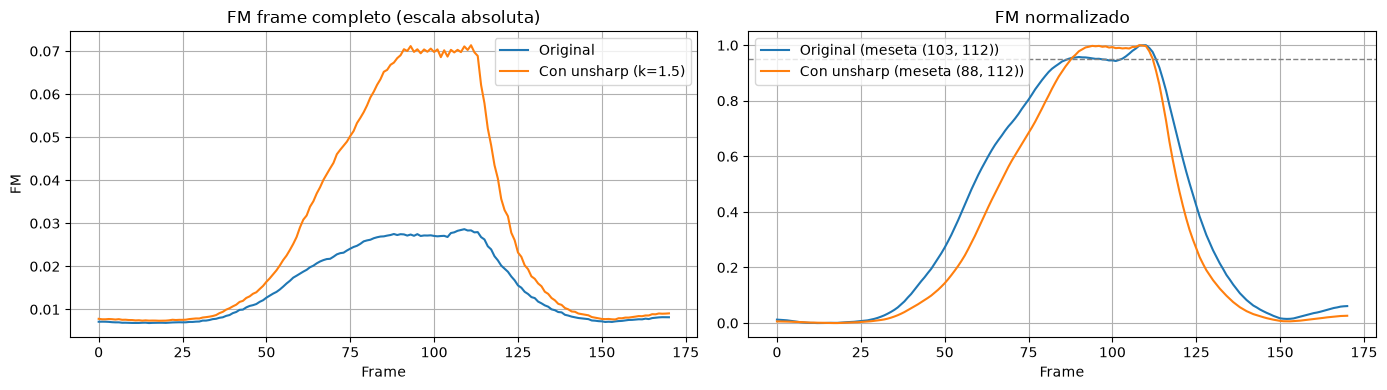

Ancho de la meseta (≥95%): original = 10 frames | con unsharp = 25 frames
Máximo: original = frame 110 | con unsharp = frame 108


In [16]:
# ¿Se expande la zona de enfoque? Se aplica unsharp a TODOS los frames y se recalcula la curva.
frames_sharp = [unsharp_mask(g, sigma=2.0, k=1.5) for g in frames_gray]
fm_full_sharp = np.array([fm_metric(g) for g in frames_sharp])
res_full_sharp = detect_max_focus(fm_full_sharp)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(fm_full, label="Original")
axes[0].plot(fm_full_sharp, label="Con unsharp (k=1.5)")
axes[0].set_title("FM frame completo (escala absoluta)")
axes[0].set_xlabel("Frame"); axes[0].set_ylabel("FM"); axes[0].legend()

axes[1].plot(normalize(res_full["curve"]), label=f"Original (meseta {res_full['plateau']})")
axes[1].plot(normalize(res_full_sharp["curve"]), label=f"Con unsharp (meseta {res_full_sharp['plateau']})")
axes[1].axhline(PLATEAU_FRAC, color="gray", ls="--", lw=1)
axes[1].set_title("FM normalizado")
axes[1].set_xlabel("Frame"); axes[1].legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "unsharp_curvas.png", dpi=150, bbox_inches="tight")
plt.show()

w0 = res_full["plateau"][1] - res_full["plateau"][0] + 1
w1 = res_full_sharp["plateau"][1] - res_full_sharp["plateau"][0] + 1
print(f"Ancho de la meseta (≥{PLATEAU_FRAC:.0%}): original = {w0} frames | con unsharp = {w1} frames")
print(f"Máximo: original = frame {res_full['best_frame']} | con unsharp = frame {res_full_sharp['best_frame']}")

**Interpretación.** Cuando el unsharp se aplica a todos los frames, la ubicación del máximo cambia muy poco, pero la meseta de enfoque se ensancha. En otras palabras, más frames quedan cerca del nivel máximo de nitidez, lo que confirma una expansión de la zona de enfoque.

## 8) Resumen

In [17]:
print("=" * 66)
print(f"Frames: {n_frames} | FPS: {fps:.2f}")
print("-" * 66)
for name, r, raw in [("Frame completo", res_full, fm_full), ("ROI 5%", res_roi5, fm_roi5), ("ROI 10%", res_roi10, fm_roi10)]:
    b = r["best_frame"]
    print(f"{name:15s}: frame {b:3d} (t={b / fps:.2f}s) | meseta {r['plateau']} | FM crudo={raw[b]:.4f}")
for name, r in res_grid.items():
    print(f"Grilla {name:16s}: frame {r['best_frame']:3d} | meseta {r['plateau']}")
print("-" * 66)
print(f"Unsharp global    -> FM: {fm0:.4f} -> {fm1:.4f}")
print(f"Unsharp localizado-> FM: {fm0:.4f} -> {fm2:.4f}")
print(f"Meseta frame completo: {w0} -> {w1} frames con unsharp")
print("=" * 66)
print("Resultados guardados en:", OUTPUT_DIR.name + "/")

Frames: 171 | FPS: 29.97
------------------------------------------------------------------
Frame completo : frame 110 (t=3.67s) | meseta (103, 112) | FM crudo=0.0283
ROI 5%         : frame 110 (t=3.67s) | meseta (106, 112) | FM crudo=0.4413
ROI 10%        : frame 110 (t=3.67s) | meseta (106, 111) | FM crudo=0.3449
Grilla Promedio        : frame  92 | meseta (88, 102)
Grilla Máximo          : frame  93 | meseta (87, 96)
Grilla Promedio top 25%: frame  94 | meseta (88, 101)
------------------------------------------------------------------
Unsharp global    -> FM: 0.0283 -> 0.0703
Unsharp localizado-> FM: 0.0283 -> 0.0491
Meseta frame completo: 10 -> 25 frames con unsharp
Resultados guardados en: outputs/


# Conclusiones

*(Corrida con `focus_video.mov`: 171 frames, 29.97 fps. Según el sistema operativo y la versión de OpenCV, los picos pueden variar ±1–2 frames.)*

La métrica FM del paper mide qué fracción de los coeficientes de la FFT supera `max/1000`: un desenfoque elimina alta frecuencia y baja FM, y un frame enfocado la conserva y sube FM. Por eso el máximo enfoque se detecta como el máximo de FM a lo largo de los frames, que es la lógica de un autofocus. El frame completo y las dos ROI centradas (5% y 10%) lo ubican en el frame **110** (t ≈ 3.67 s), y la energía del gradiente de Sobel, una métrica de otra naturaleza, lo ubica en el frame 109. La meseta al 95% es angosta (≈10 frames en el frame completo), así que el pico está bien definido. Los valores absolutos de FM no son comparables entre regiones de distinto tamaño (≈0.028, ≈0.44 y ≈0.34), por lo que la comparación se hizo sobre curvas normalizadas: las ROI suben más tarde y caen más abruptamente que el frame completo. Con un umbral `max/100` la métrica pierde poder discriminativo, y `max/1000` (el del paper) funciona bien.

La matriz de enfoque promediada sobre toda la grilla ubica el máximo en los frames ≈92–94, no en 110, y la agregación por máximo de celdas da una curva ruidosa con varios picos comparables. Una posible explicación, que no se verificó, es que las celdas del fondo (la mayoría) enfocan en un momento distinto al del objeto central y arrastran el promedio. Para decidir el foco de un objeto conviene usar una ROI sobre ese objeto en lugar de promediar toda la grilla.

En el punto extra, el unsharp masking sube el FM (≈0.028 → ≈0.07 global y ≈0.05 localizado), pero eso es esperable por construcción del filtro y no prueba por sí solo que la imagen esté más enfocada. La evidencia más relevante es que, aplicado a todos los frames, la meseta al 95% pasa de ≈10 a ≈25 frames: la zona de enfoque aceptable se expande. Como contrapartida, el filtro también amplifica ruido y artefactos de compresión.